# Fully-connected feedforward neural networks with one or more hidden layers



## XOR Problem

In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import time
import matplotlib.pyplot as plt
%matplotlib inline

RANDOM_SEED = 123
DEVICE = ('cuda:0' if torch.cuda.is_available() else 'cpu')

- `torch`: biblioteca de aprendizado de máquina que permite construção de redes neurais.
- `torch.nn.functional`: módulo para funções como ativação e perda.
- `pandas`: biblioteca para manipulação de dados estruturados.
- `time`: usada para medir o tempo de execução.
- `matplotlib.pyplot`: biblioteca para plotagem de gráficos.
- `%matplotlib inline`: comando do Jupyter/Google Colab para exibir gráficos diretamente.
- Define uma semente fixa para garantir reprodutibilidade.
- Detecta se há uma GPU disponível para uso, o que melhora a performance no treinamento.

In [ ]:
df = pd.read_csv('xor.csv')
print(df.head())
X = df[['x1', 'x2']].values
y = df['class label'].values

         x1        x2  class label
0  0.781306  1.062984            0
1 -1.060524 -1.095550            0
2  0.632125  0.674028            0
3 -1.424712  0.535203            1
4  1.383161  1.368510            0


- Carrega o dataset `xor.csv`.
- Exibe as cinco primeiras amostras com `df.head()`.
- `X` recebe as duas variáveis de entrada `x1` e `x2`.
- `y` armazena os rótulos das classes (`0` ou `1`).

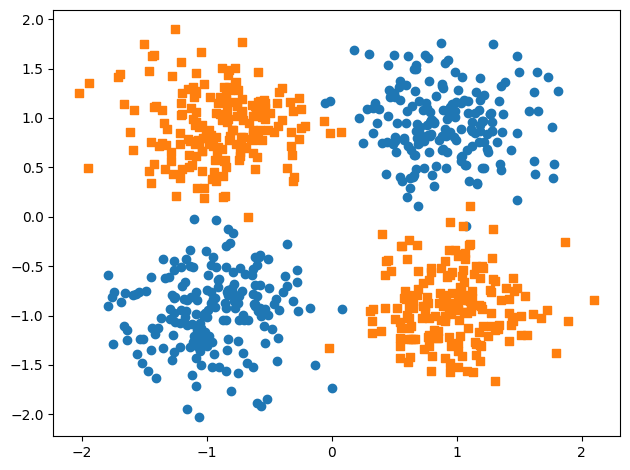

In [ ]:
plt.scatter(X[y==0, 0], X[y==0, 1], marker='o')
plt.scatter(X[y==1, 0], X[y==1, 1], marker='s')

plt.tight_layout()
plt.show()

- Plota os dados de entrada separadamente para as duas classes (`0` e `1`).
- `marker='o'` e `marker='s'` definem formatos diferentes para cada classe.

In [ ]:
class MLPLinear(torch.nn.Module):
    def __init__(self, num_features, num_hidden_1, num_classes):
        super(MLPLinear, self).__init__()

        self.num_classes = num_classes

        self.linear_1 = torch.nn.Linear(num_features, num_hidden_1)
        self.linear_out = torch.nn.Linear(num_hidden_1, num_classes)

    def forward(self, x):

        out = self.linear_1(x)
        #out = F.relu(out)

        logits = self.linear_out(out)
        probas = F.softmax(logits, dim=1)
        return logits, probas

- Cria uma classe que herda de `torch.nn.Module`.
- `linear_1`: camada totalmente conectada que mapeia da entrada para a camada oculta.
- `linear_out`: camada de saída que mapeia da camada oculta para a saída.

`def forward`
- Passa os dados pela camada linear `linear_1`.
- Aplica `softmax` à saída da rede para obter as probabilidades por classe.

In [ ]:
torch.manual_seed(RANDOM_SEED)

model1 = MLPLinear(num_features=2,
                   num_hidden_1=50,
                   num_classes=2)

model1 = model1.to(DEVICE)

optimizer = torch.optim.SGD(model1.parameters(), lr=0.1)

- Define a semente para reprodutibilidade.
- Inicializa o modelo com 2 entradas, 50 neurônios na camada oculta e 2 classes de saída.
- Move o modelo para GPU se disponível.
- Define o otimizador [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) com taxa de aprendizado de 0.1.

In [ ]:
start_time = time.time()
minibatch_cost = []

NUM_EPOCHS = 50

features = torch.tensor(X, dtype=torch.float).to(DEVICE)
targets = torch.tensor(y, dtype=torch.long).to(DEVICE)

for epoch in range(NUM_EPOCHS):

    ### FORWARD AND BACK PROP
    logits, probas = model1(features)

    cost = F.cross_entropy(logits, targets)
    optimizer.zero_grad()

    cost.backward()
    minibatch_cost.append(cost)
    ### UPDATE MODEL PARAMETERS
    optimizer.step()

    ### LOGGING

    print (f'Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d} | Cost: {cost:.4f}')


print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/050 | Cost: 0.7075
Epoch: 002/050 | Cost: 0.6980
Epoch: 003/050 | Cost: 0.6946
Epoch: 004/050 | Cost: 0.6933
Epoch: 005/050 | Cost: 0.6929
Epoch: 006/050 | Cost: 0.6928
Epoch: 007/050 | Cost: 0.6927
Epoch: 008/050 | Cost: 0.6927
Epoch: 009/050 | Cost: 0.6927
Epoch: 010/050 | Cost: 0.6927
Epoch: 011/050 | Cost: 0.6927
Epoch: 012/050 | Cost: 0.6927
Epoch: 013/050 | Cost: 0.6927
Epoch: 014/050 | Cost: 0.6927
Epoch: 015/050 | Cost: 0.6927
Epoch: 016/050 | Cost: 0.6927
Epoch: 017/050 | Cost: 0.6927
Epoch: 018/050 | Cost: 0.6927
Epoch: 019/050 | Cost: 0.6927
Epoch: 020/050 | Cost: 0.6927
Epoch: 021/050 | Cost: 0.6927
Epoch: 022/050 | Cost: 0.6927
Epoch: 023/050 | Cost: 0.6927
Epoch: 024/050 | Cost: 0.6927
Epoch: 025/050 | Cost: 0.6927
Epoch: 026/050 | Cost: 0.6927
Epoch: 027/050 | Cost: 0.6927
Epoch: 028/050 | Cost: 0.6927
Epoch: 029/050 | Cost: 0.6927
Epoch: 030/050 | Cost: 0.6927
Epoch: 031/050 | Cost: 0.6927
Epoch: 032/050 | Cost: 0.6927
Epoch: 033/050 | Cost: 0.6927
Epoch: 034

- Converte `X` e `y` para tensores PyTorch.
- Itera por 25 épocas, calculando o custo com `cross_entropy`.
- Zera os gradientes com `optimizer.zero_grad()`, realiza backpropagation e atualiza os pesos.
- Printa o custo por época.

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np


def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    tensor = torch.tensor(np.array([xx1.ravel(), xx2.ravel()]).T).float()
    logits, probas = classifier.forward(tensor)
    Z = np.argmax(probas.detach().numpy(), axis=1)

    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, color=cmap(idx),
                    edgecolor='black',
                    marker=markers[idx],
                    label=cl)

- Plota a superfície de decisão do modelo.
- Gera uma malha de pontos para prever as classes e colore a área de decisão.
- Plota as amostras de dados com cores distintas.

<ipython-input-29-b4b48bfb12e8>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


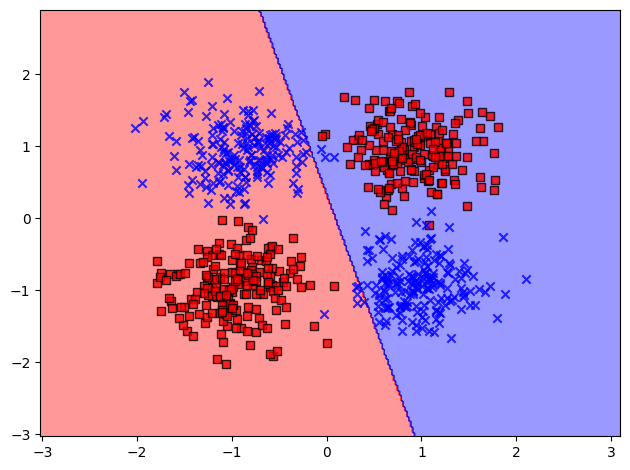

In [ ]:
plot_decision_regions(features, targets, classifier=model1)

plt.tight_layout()
#plt.savefig('xor1.pdf')
plt.show()

# Multilayer Perceptron with Non-Linear Activations (ReLU)

In [ ]:
class MLPReLU(torch.nn.Module):

    def __init__(self, num_features, num_hidden_1, num_classes):
        super(MLPReLU, self).__init__()

        self.num_classes = num_classes

        self.linear_1 = torch.nn.Linear(num_features, num_hidden_1)
        self.linear_out = torch.nn.Linear(num_hidden_1, num_classes)

    def forward(self, x):

        out = self.linear_1(x)
        out = F.relu(out)

        logits = self.linear_out(out)
        probas = F.softmax(logits, dim=1)
        return logits, probas

In [ ]:
torch.manual_seed(RANDOM_SEED)

model2 = MLPReLU(num_features=2,
                num_hidden_1=50,
                num_classes=2)

model2 = model2.to(DEVICE)

optimizer = torch.optim.SGD(model2.parameters(), lr=0.1)

In [ ]:
start_time = time.time()
minibatch_cost = []

NUM_EPOCHS = 100

features = torch.tensor(X, dtype=torch.float).to(DEVICE)
targets = torch.tensor(y, dtype=torch.long).to(DEVICE)

for epoch in range(NUM_EPOCHS):

    ### FORWARD AND BACK PROP
    logits, probas = model2(features)

    cost = F.cross_entropy(logits, targets)
    optimizer.zero_grad()

    cost.backward()
    minibatch_cost.append(cost)
    ### UPDATE MODEL PARAMETERS
    optimizer.step()

    ### LOGGING

    print (f'Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d} | Cost: {cost:.4f}')


print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/100 | Cost: 0.2079
Epoch: 002/100 | Cost: 0.2043
Epoch: 003/100 | Cost: 0.2008
Epoch: 004/100 | Cost: 0.1973
Epoch: 005/100 | Cost: 0.1940
Epoch: 006/100 | Cost: 0.1908
Epoch: 007/100 | Cost: 0.1877
Epoch: 008/100 | Cost: 0.1847
Epoch: 009/100 | Cost: 0.1817
Epoch: 010/100 | Cost: 0.1789
Epoch: 011/100 | Cost: 0.1761
Epoch: 012/100 | Cost: 0.1734
Epoch: 013/100 | Cost: 0.1708
Epoch: 014/100 | Cost: 0.1683
Epoch: 015/100 | Cost: 0.1658
Epoch: 016/100 | Cost: 0.1634
Epoch: 017/100 | Cost: 0.1611
Epoch: 018/100 | Cost: 0.1588
Epoch: 019/100 | Cost: 0.1566
Epoch: 020/100 | Cost: 0.1544
Epoch: 021/100 | Cost: 0.1523
Epoch: 022/100 | Cost: 0.1503
Epoch: 023/100 | Cost: 0.1483
Epoch: 024/100 | Cost: 0.1464
Epoch: 025/100 | Cost: 0.1445
Epoch: 026/100 | Cost: 0.1426
Epoch: 027/100 | Cost: 0.1408
Epoch: 028/100 | Cost: 0.1391
Epoch: 029/100 | Cost: 0.1374
Epoch: 030/100 | Cost: 0.1357
Epoch: 031/100 | Cost: 0.1341
Epoch: 032/100 | Cost: 0.1325
Epoch: 033/100 | Cost: 0.1310
Epoch: 034

<ipython-input-29-b4b48bfb12e8>:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


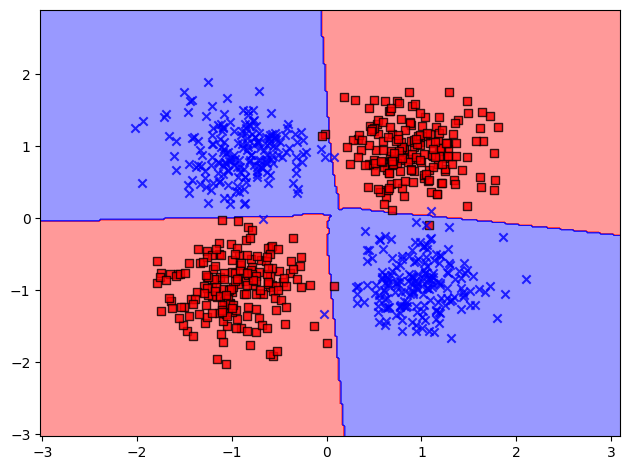

In [ ]:
plot_decision_regions(features, targets, classifier=model2)

plt.tight_layout()
#plt.savefig('xor2.pdf')
plt.show()

# MLP usando Função de ativação Sigmoid e Erro quadrático médio (MSE)

In [ ]:
import time
import numpy as np
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch

Dataset - [MNIST](https://en.wikipedia.org/wiki/MNIST_database)

In [ ]:
RANDOM_SEED = 1
BATCH_SIZE = 100
NUM_EPOCHS = 50

# Note transforms.ToTensor() reescala input
# para intervalo 0-1
train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms.ToTensor())


train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Checking the dataset
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([100, 1, 28, 28])
Image label dimensions: torch.Size([100])


```python
RANDOM_SEED = 1
BATCH_SIZE = 100
NUM_EPOCHS = 50
```
- **RANDOM_SEED**: Define uma semente para a inicialização de números aleatórios, garantindo reprodutibilidade dos resultados.
- **BATCH_SIZE**: Tamanho de cada lote de dados usado durante o treinamento.
- **NUM_EPOCHS**: Número de vezes que o modelo será treinado em todo o conjunto de dados.

### **Carregamento do Dataset MNIST**
```python
train_dataset = datasets.MNIST(root='data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transforms.ToTensor())
```
- **datasets.MNIST**: Carrega o dataset MNIST.
- **root='data'**: Diretório onde os dados serão armazenados.
- **train=True/False**: Carrega os dados de treinamento ou teste.
- **transform=transforms.ToTensor()**: Converte as imagens para tensores PyTorch e escala os valores para a faixa `[0, 1]`.
- **download=True**: Faz o download do conjunto de dados se ele não estiver presente no diretório especificado.

### **DataLoaders**
```python
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
```
- **DataLoader**: Cria iteradores eficientes para carregar os dados em mini-batches.
- **batch_size=BATCH_SIZE**: Define o tamanho dos mini-batches.
- **shuffle=True/False**: Embaralha os dados no treinamento (mas não no teste).

### **Verificação do Dataset**
```python
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break
```
- Imprime as dimensões de um lote de imagens e rótulos para garantir que o DataLoader está configurado corretamente.


Modelo - MLP

In [ ]:
class MultilayerPerceptron():

    def __init__(self, num_features, num_hidden, num_classes):
        super(MultilayerPerceptron, self).__init__()

        self.num_classes = num_classes

        # hidden 1
        self.weight_1 = torch.zeros(num_hidden, num_features,
                                    dtype=torch.float).normal_(0.0, 0.1)
        self.bias_1 = torch.zeros(num_hidden, dtype=torch.float)

        # output
        self.weight_o = torch.zeros(self.num_classes, num_hidden,
                                    dtype=torch.float).normal_(0.0, 0.1)
        self.bias_o = torch.zeros(self.num_classes, dtype=torch.float)

    def forward(self, x):
        # hidden 1

        # input dim: [n_hidden, n_features] dot [n_features, n_examples].T
        # output dim: [n_examples, n_hidden]
        z_1 = torch.mm(x, self.weight_1.t()) + self.bias_1
        a_1 = torch.sigmoid(z_1)

        # hidden 2
        # input dim: [n_classes, n_hidden] dot [n_hidden, n_examples].T
        # output dim: [n_examples, n_classes]
        z_2 = torch.mm(a_1, self.weight_o.t()) + self.bias_o
        a_2 = torch.sigmoid(z_2)
        return a_1, a_2

    def backward(self, x, a_1, a_2, y):
        # onehot encoding
        y_onehot = torch.FloatTensor(y.size(0), self.num_classes)
        y_onehot.zero_()
        y_onehot.scatter_(1, y.view(-1, 1).long(), 1)


        # Part 1: dLoss/dOutWeights - Regra da Cadeia - Delta Rule
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use

        # input/output dim: [n_examples, n_classes]
        dloss_da2 = 2.*(a_2 - y_onehot) / y.size(0)

        # input/output dim: [n_examples, n_classes]
        da2_dz2 = a_2 * (1. - a_2) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = dloss_da2 * da2_dz2 # "delta (rule) placeholder"

        # gradient for output weights

        # [n_examples, n_hidden]
        dz2__dw_out = a_1

        # input dim: [n_classlabels, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classlabels, n_hidden]
        dloss__dw_out = torch.mm(delta_out.t(), dz2__dw_out)
        dloss__db_out = torch.sum(delta_out, dim=0)


        #################################
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight

        # [n_classes, n_hidden]
        dz2__a1 = self.weight_o

        # output dim: [n_examples, n_hidden]
        dloss_a1 = torch.mm(delta_out, dz2__a1)

        # [n_examples, n_hidden]
        da1__dz1 = a_1 * (1. - a_1) # sigmoid derivative

        # [n_examples, n_features]
        dz1__dw1 = x

        # output dim: [n_hidden, n_features]
        dloss_dw1 = torch.mm((dloss_a1 * da1__dz1).t(), dz1__dw1)
        dloss_db1 = torch.sum((dloss_a1 * da1__dz1), dim=0)

        return dloss__dw_out, dloss__db_out, dloss_dw1, dloss_db1

```python
class MultilayerPerceptron():
    def __init__(self, num_features, num_hidden, num_classes):
        super(MultilayerPerceptron, self).__init__()
```
### **Construtor**
- **num_features**: Número de características (entradas), que para MNIST é `28x28=784`.
- **num_hidden**: Número de neurônios na camada oculta.
- **num_classes**: Número de classes de saída, que é `10` para o MNIST.

```python
self.weight_1 = torch.zeros(num_hidden, num_features, dtype=torch.float).normal_(0.0, 0.1)
self.bias_1 = torch.zeros(num_hidden, dtype=torch.float)
self.weight_o = torch.zeros(self.num_classes, num_hidden, dtype=torch.float).normal_(0.0, 0.1)
self.bias_o = torch.zeros(self.num_classes, dtype=torch.float)
```
- **self.weight_1**: Pesos da camada oculta inicializados aleatoriamente com média `0` e desvio padrão `0.1`.
- **self.bias_1**: Bias da camada oculta inicializados como zeros.
- **self.weight_o**: Pesos da camada de saída inicializados aleatoriamente.
- **self.bias_o**: Bias da camada de saída inicializados como zeros.

**Explicação**: Os pesos da camada oculta (representados por `self.weight_1`) são inicializados de forma aleatória com média 0 e desvio padrão 0.1. Esta inicialização tem um propósito importante:

- **Inicialização Aleatória**: Quando se treina redes neurais, é essencial que os pesos comecem com valores aleatórios (não zeros) para que o modelo possa aprender de forma eficaz. Se todos os pesos começassem com o mesmo valor (como zeros), o modelo não conseguiria aprender a partir de diferentes características dos dados de entrada.
  
- **Normalização (média 0 e desvio padrão 0.1)**:
  - A escolha de uma distribuição normal com média `0` e desvio padrão `0.1` ajuda a garantir que a distribuição inicial dos pesos seja razoavelmente balanceada e não cause grandes desvios no início do treinamento.
  - O desvio padrão pequeno (0.1) ajuda a evitar que os valores dos pesos sejam muito grandes logo de cara, o que poderia causar problemas como gradientes explodindo durante o treinamento (explosão do gradiente).

---

### **Forward Pass (`forward`)**
```python
z_1 = torch.mm(x, self.weight_1.t()) + self.bias_1
a_1 = torch.sigmoid(z_1)
```
- **z_1 = Wx + b**: Multiplicação linear dos dados de entrada com os pesos e soma do bias.
- **a_1 = sigmoid(z_1)**: Aplicação da função de ativação sigmoide.

```python
z_2 = torch.mm(a_1, self.weight_o.t()) + self.bias_o
a_2 = torch.sigmoid(z_2)
```
- **z_2 = Wx + b** na camada de saída.
- **a_2**: Saída final da rede após aplicar a função de ativação sigmoide.

---

### **Backward Pass (`backward`)**
#### **Backward na Camada de Saída**
```python
y_onehot = torch.FloatTensor(y.size(0), self.num_classes)
y_onehot.zero_()
y_onehot.scatter_(1, y.view(-1, 1).long(), 1)
```
- Codificação one-hot dos rótulos.

**Explicação**: O que está acontecendo aqui é a **conversão dos rótulos** (labels) em um formato chamado **one-hot encoding**.

1. **`y.size(0)`**: Retorna o número de exemplos (ou seja, o tamanho do vetor `y`, que contém os rótulos das classes para cada exemplo).

2. **`torch.FloatTensor(y.size(0), self.num_classes)`**: Cria uma matriz de zeros de tamanho `[n_samples, num_classes]`, onde `n_samples` é o número de exemplos no lote, e `num_classes` é o número de classes no problema (10 para o MNIST).

3. **`y_onehot.zero_()`**: Inicializa todos os elementos dessa matriz como 0.

4. **`y_onehot.scatter_(1, y.view(-1, 1).long(), 1)`**:
   - **`scatter_(1, ...)`**: A função `scatter` é usada para preencher um tensor de acordo com os índices. O primeiro parâmetro `1` significa que estamos fazendo isso ao longo das colunas.
   - **`y.view(-1, 1)`**: O vetor `y`, que contém os rótulos de classe para cada exemplo, é transformado em um vetor de uma única coluna. Por exemplo, se `y = [2, 0, 3]`, então `y.view(-1, 1)` será algo como:
     ```
     [2]
     [0]
     [3]
     ```
   - **`long()`**: Garante que os índices sejam do tipo inteiro (long).
   - **`1`**: Substitui os elementos do tensor `y_onehot` nos índices indicados por 1.

**Resultado**: Depois de executar esse código, cada rótulo (classe) será transformado em um vetor de tamanho `num_classes` onde o valor correspondente ao índice da classe será `1` e todos os outros valores serão `0`. Isso é útil porque, em redes neurais, muitas vezes trabalhamos com o formato de **probabilidade** das classes (como um vetor de probabilidades) e a comparação entre a saída da rede e a verdade dos dados é mais eficaz quando os rótulos são representados dessa maneira.

Exemplo:
- Se a classe de um exemplo é `2`, o vetor one-hot será `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`.

```python
dloss_da2 = 2.*(a_2 - y_onehot) / y.size(0)
da2_dz2 = a_2 * (1. - a_2)
delta_out = dloss_da2 * da2_dz2
```
- **dloss_da2**: Gradiente da perda em relação à saída.
- **da2_dz2**: Derivada da sigmoide.
- **delta_out**: Delta da camada de saída (gradiente acumulado).

```python
dloss__dw_out = torch.mm(delta_out.t(), a_1)
dloss__db_out = torch.sum(delta_out, dim=0)
```
- Gradientes para pesos e bias da camada de saída.

#### **Backward na Camada Oculta**
```python
dz2__a1 = self.weight_o
dloss_a1 = torch.mm(delta_out, dz2__a1)
da1__dz1 = a_1 * (1. - a_1)
dloss_dw1 = torch.mm((dloss_a1 * da1__dz1).t(), x)
dloss_db1 = torch.sum((dloss_a1 * da1__dz1), dim=0)
```
- **dz2__a1**: Pesos da camada de saída.
- **dloss_a1**: Gradiente acumulado para a camada oculta.
- **dloss_dw1, dloss_db1**: Gradientes para os pesos e bias da camada oculta.


Treino

In [ ]:
def to_onehot(y, num_classes):
    y_onehot = torch.FloatTensor(y.size(0), num_classes)
    y_onehot.zero_()
    y_onehot.scatter_(1, y.view(-1, 1).long(), 1).float()
    return y_onehot


def loss_func(targets_onehot, probas_onehot):
    return torch.mean(torch.mean((targets_onehot - probas_onehot)**2, dim=0))


def compute_mse(net, data_loader):
    curr_mse, num_examples = torch.zeros(model.num_classes).float(), 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28)
            logits, probas = net.forward(features)
            y_onehot = to_onehot(targets, model.num_classes)
            loss = torch.sum((y_onehot - probas)**2, dim=0)
            num_examples += targets.size(0)
            curr_mse += loss

        curr_mse = torch.mean(curr_mse/num_examples, dim=0)
        return curr_mse


def train(model, data_loader, num_epochs,
          learning_rate=0.1):
    minibatch_cost = []
    epoch_cost = []

    for e in range(num_epochs):

        for batch_idx, (features, targets) in enumerate(train_loader):

            features = features.view(-1, 28*28)

            #### Compute outputs ####
            a_1, a_2 = model.forward(features)

            #### Compute gradients ####
            dloss__dw_out, dloss__db_out, dloss_dw1, dloss_db1 = \
                model.backward(features, a_1, a_2, targets)

            #### Update weights ####
            model.weight_1 -= learning_rate * dloss_dw1
            model.bias_1 -= learning_rate * dloss_db1
            model.weight_o -= learning_rate * dloss__dw_out
            model.bias_o -= learning_rate * dloss__db_out

            #### Logging ####
            curr_cost = loss_func(to_onehot(targets, model.num_classes), a_2)
            minibatch_cost.append(curr_cost)
            if not batch_idx % 50:
                print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f'
                       %(e+1, NUM_EPOCHS, batch_idx,
                         len(train_loader), curr_cost))

        #### Logging ####
        curr_cost = compute_mse(model, train_loader)
        epoch_cost.append(curr_cost)
        print('Epoch: %03d/%03d |' % (e+1, NUM_EPOCHS), end="")
        print(' Train MSE: %.5f' % curr_cost)

    return minibatch_cost, epoch_cost

### **Função `to_onehot()`**
```python
def to_onehot(y, num_classes):
    y_onehot = torch.FloatTensor(y.size(0), num_classes)
    y_onehot.zero_()
    y_onehot.scatter_(1, y.view(-1, 1).long(), 1).float()
    return y_onehot
```
- Transforma os rótulos em formato one-hot para compatibilidade com a função de perda.

---

### **Função de Perda (`loss_func`)**
```python
def loss_func(targets_onehot, probas_onehot):
    return torch.mean(torch.mean((targets_onehot - probas_onehot)**2, dim=0))
```
- Implementa a perda de **Erro Médio Quadrático (MSE)**.

---

### **Cálculo do MSE (`compute_mse`)**
```python
def compute_mse(net, data_loader):
    curr_mse, num_examples = torch.zeros(model.num_classes).float(), 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28)
            logits, probas = net.forward(features)
            y_onehot = to_onehot(targets, model.num_classes)
            loss = torch.sum((y_onehot - probas)**2, dim=0)
            num_examples += targets.size(0)
            curr_mse += loss

        curr_mse = torch.mean(curr_mse/num_examples, dim=0)
        return curr_mse
```
- Avalia o MSE em um conjunto de dados, desabilitando o gradiente com `torch.no_grad()`.


**Explicação**: O `torch.no_grad()` é utilizado para **desabilitar o cálculo de gradientes** durante uma operação, o que é importante por várias razões:

- **Avaliação do Modelo (sem retropropagação)**: Durante o treinamento, o cálculo de gradientes é necessário para a retropropagação, mas **durante a fase de avaliação (testes), não precisamos calcular ou armazenar gradientes**. Isso pode economizar muita memória e tempo de computação.
  
- **Evitar Cálculo Desnecessário**: Em muitos casos, no processo de validação ou teste de um modelo, as operações de gradiente não são necessárias, pois não estamos ajustando os pesos. Portanto, desabilitar o cálculo de gradientes com `torch.no_grad()` economiza recursos computacionais.

- **Uso de Memória**: Cada operação no PyTorch que envolve cálculos de gradiente exige o armazenamento de informações intermediárias, o que pode ser caro em termos de memória. Durante a fase de **inferência**, não precisamos dessas informações, então, usando `torch.no_grad()`, o PyTorch não mantém essas variáveis intermediárias, economizando memória.

- Resumo: Utilizamos `torch.no_grad()` para garantir que, durante a fase de teste ou avaliação do modelo, não haverá cálculos de gradientes desnecessários, o que torna o processo mais eficiente em termos de memória e velocidade.
---

### **Treinamento (`train`)**
```python
def train(model, data_loader, num_epochs, learning_rate=0.1):
    minibatch_cost = []
    epoch_cost = []

    for e in range(num_epochs):
        for batch_idx, (features, targets) in enumerate(train_loader):
            features = features.view(-1, 28*28)
            a_1, a_2 = model.forward(features)
            dloss__dw_out, dloss__db_out, dloss_dw1, dloss_db1 = model.backward(features, a_1, a_2, targets)
            model.weight_1 -= learning_rate * dloss_dw1
            model.bias_1 -= learning_rate * dloss_db1
            model.weight_o -= learning_rate * dloss__dw_out
            model.bias_o -= learning_rate * dloss__db_out
```
- Calcula os gradientes e atualiza os pesos manualmente (sem PyTorch `optim`).

In [ ]:
torch.manual_seed(RANDOM_SEED)

model = MultilayerPerceptron(num_features=28*28,
                             num_hidden=50,
                             num_classes=10)

minibatch_cost, epoch_cost = train(model,
                                  train_loader,
                                  num_epochs=NUM_EPOCHS,
                                  learning_rate=0.1)

Epoch: 001/050 | Batch 000/600 | Cost: 0.2453
Epoch: 001/050 | Batch 050/600 | Cost: 0.0886
Epoch: 001/050 | Batch 100/600 | Cost: 0.0890
Epoch: 001/050 | Batch 150/600 | Cost: 0.0867
Epoch: 001/050 | Batch 200/600 | Cost: 0.0851
Epoch: 001/050 | Batch 250/600 | Cost: 0.0846
Epoch: 001/050 | Batch 300/600 | Cost: 0.0822
Epoch: 001/050 | Batch 350/600 | Cost: 0.0779
Epoch: 001/050 | Batch 400/600 | Cost: 0.0768
Epoch: 001/050 | Batch 450/600 | Cost: 0.0765
Epoch: 001/050 | Batch 500/600 | Cost: 0.0737
Epoch: 001/050 | Batch 550/600 | Cost: 0.0685
Epoch: 001/050 | Train MSE: 0.06579
Epoch: 002/050 | Batch 000/600 | Cost: 0.0667
Epoch: 002/050 | Batch 050/600 | Cost: 0.0592
Epoch: 002/050 | Batch 100/600 | Cost: 0.0574
Epoch: 002/050 | Batch 150/600 | Cost: 0.0581
Epoch: 002/050 | Batch 200/600 | Cost: 0.0498
Epoch: 002/050 | Batch 250/600 | Cost: 0.0520
Epoch: 002/050 | Batch 300/600 | Cost: 0.0516
Epoch: 002/050 | Batch 350/600 | Cost: 0.0511
Epoch: 002/050 | Batch 400/600 | Cost: 0.048

```python
torch.manual_seed(RANDOM_SEED)
```
- Esta linha garante que a inicialização dos pesos e outros elementos aleatórios sejam reproduzíveis. Usar uma semente fixa permite que o treinamento tenha os mesmos resultados sempre que o código for executado.

### **Instanciação do Modelo**
```python
model = MultilayerPerceptron(num_features=28*28, num_hidden=50, num_classes=10)
```
- Instancia a classe `MultilayerPerceptron`, passando os parâmetros de entrada:
  - **num_features**: 784 (pois cada imagem é de 28x28 pixels).
  - **num_hidden**: 50 (número de neurônios na camada oculta).
  - **num_classes**: 10 (número de classes do MNIST).

### **Treinamento do Modelo**
```python
minibatch_cost, epoch_cost = train(model, train_loader, num_epochs=NUM_EPOCHS, learning_rate=0.1)
```
- Chama a função `train`, que realiza o treinamento do modelo por 50 épocas, usando a taxa de aprendizado de 0.1.
- **minibatch_cost**: Lista que armazenará os custos por mini-lote durante o treinamento.
- **epoch_cost**: Lista que armazenará os custos médios por época.

Avaliação

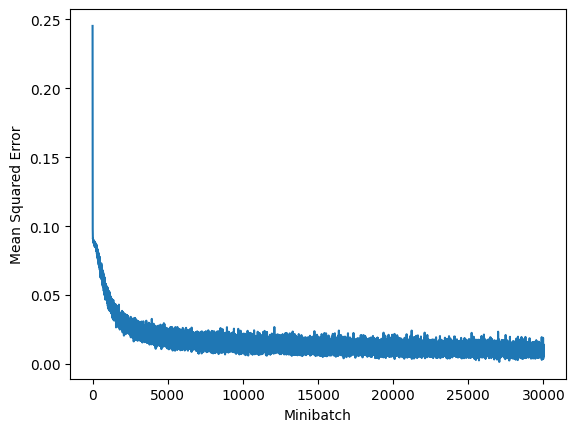

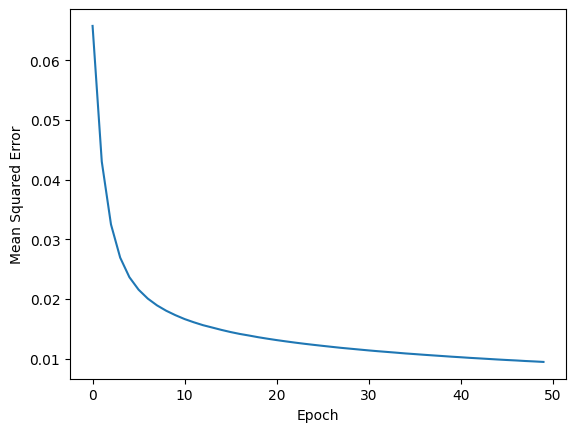

In [ ]:
plt.plot(range(len(minibatch_cost)), minibatch_cost)
plt.ylabel('Mean Squared Error')
plt.xlabel('Minibatch')
plt.show()

plt.plot(range(len(epoch_cost)), epoch_cost)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.show()

In [ ]:
def compute_accuracy(net, data_loader):
    correct_pred, num_examples = 0, 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28)
            _, outputs = net.forward(features)
            predicted_labels = torch.argmax(outputs, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
        return correct_pred.float()/num_examples * 100

print('Training Accuracy: %.2f' % compute_accuracy(model, train_loader))
print('Test Accuracy: %.2f' % compute_accuracy(model, test_loader))

Training Accuracy: 94.71
Test Accuracy: 94.51


### **Função de Cálculo de Acurácia**
- **Objetivo**: Calcular a acurácia do modelo em um conjunto de dados, como o conjunto de treinamento ou teste.
  
#### **Explicação Detalhada**:
1. **Inicialização**:
   ```python
   correct_pred, num_examples = 0, 0
   ```
   Inicializa o contador de previsões corretas e o número total de exemplos.

2. **Iteração pelos Dados**:
   ```python
   with torch.no_grad():
       for features, targets in data_loader:
           features = features.view(-1, 28*28)
   ```
   - **`torch.no_grad()`**: Desabilita o cálculo de gradientes, já que estamos apenas avaliando o modelo, sem a necessidade de retropropagação.
   - **`features.view(-1, 28*28)`**: Redimensiona as imagens para o formato adequado (784 características por imagem).

3. **Previsões**:
   ```python
   _, outputs = net.forward(features)
   predicted_labels = torch.argmax(outputs, 1)
   ```
   - **`net.forward(features)`**: Obtém as probabilidades de cada classe (saída da rede).
   - **`torch.argmax(outputs, 1)`**: Obtém o índice da classe com maior probabilidade para cada exemplo.

4. **Cálculo da Acurácia**:
   ```python
   correct_pred += (predicted_labels == targets).sum()
   num_examples += targets.size(0)
   ```

   - **`(predicted_labels == targets)`**: Compara as previsões com os rótulos verdadeiros e retorna um tensor de valores booleanos.
   - **`.sum()`**: Conta o número de previsões corretas.
   
5. **Retorno da Acurácia**:
   ```python
   return correct_pred.float()/num_examples * 100
   ```
   Calcula a acurácia como a razão de previsões corretas sobre o total de exemplos, multiplicada por 100 para obter a porcentagem.

### **Acurácia no Treinamento e Teste**
```python
print('Training Accuracy: %.2f' % compute_accuracy(model, train_loader))
print('Test Accuracy: %.2f' % compute_accuracy(model, test_loader))
```
- Exibe a acurácia do modelo nos conjuntos de treinamento e teste.

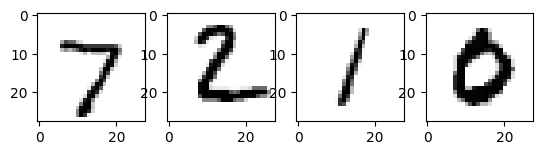

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

for features, targets in test_loader:
    break

fig, ax = plt.subplots(1, 4)
for i in range(4):
    ax[i].imshow(features[i].view(28, 28), cmap=matplotlib.cm.binary)

plt.show()

In [ ]:
_, predictions = model.forward(features[:4].view(-1, 28*28))
predictions = torch.argmax(predictions, dim=1)
print('Predicted labels', predictions)

Predicted labels tensor([7, 2, 1, 0])


### **Fazendo Previsões e Exibindo os Resultados**
1. **Previsões para 4 Imagens**:
   ```python
   _, predictions = model.forward(features[:4].view(-1, 28*28))
   ```
   - Realiza a previsão para as 4 primeiras imagens do lote.

2. **Obtenção da Classe Predita**:
   ```python
   predictions = torch.argmax(predictions, dim=1)
   ```
   - **`torch.argmax(predictions, dim=1)`**: Retorna a classe predita (índice da maior probabilidade) para cada uma das 4 imagens.

3. **Exibição das Labels Preditas**:
   ```python
   print('Predicted labels', predictions)
   ```

4. **Exibe a Imagem**:
   ```python
   plt.show()
   ```

# Multilayer Perceptron in Python with Sigmoid Output and MSE Loss usando pyTorch

In [ ]:
import time
import numpy as np
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch

In [ ]:
RANDOM_SEED = 1
BATCH_SIZE = 100
NUM_EPOCHS = 100
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##########################
### MNIST DATASET
##########################

# Note transforms.ToTensor() scales input images
# to 0-1 range
train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms.ToTensor())


train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Checking the dataset
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([100, 1, 28, 28])
Image label dimensions: torch.Size([100])


In [ ]:
def to_onehot(y, num_classes):
    y_onehot = torch.FloatTensor(y.size(0), num_classes)
    y_onehot.zero_()
    tmp = y.view(-1, 1).long().to(torch.device('cpu'))
    y_onehot.scatter_(1, tmp, 1).float()
    return y_onehot

Modelo

In [ ]:
class MlpSigmoidMSE(torch.nn.Module):

    def __init__(self, num_features, num_hidden, num_classes):
        super(MlpSigmoidMSE, self).__init__()

        self.num_classes = num_classes

        ### 1st hidden layer
        self.linear_1 = torch.nn.Linear(num_features, num_hidden)
        self.linear_1.weight.detach().normal_(0.0, 0.1)
        self.linear_1.bias.detach().zero_()

        ### Output layer
        self.linear_out = torch.nn.Linear(num_hidden, num_classes)
        self.linear_out.weight.detach().normal_(0.0, 0.1)
        self.linear_out.bias.detach().zero_()

    def forward(self, x):
        out = self.linear_1(x)
        out = torch.sigmoid(out)
        logits = self.linear_out(out)
        probas = torch.sigmoid(logits)
        return logits, probas


#################################
### Model Initialization
#################################

torch.manual_seed(RANDOM_SEED)
model = MlpSigmoidMSE(num_features=28*28,
                      num_hidden=100,
                      num_classes=10)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

#################################
### Training
#################################

def compute_mse(net, data_loader):
    curr_mse, num_examples = torch.zeros(model.num_classes).float(), 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28).to(DEVICE)
            logits, probas = net.forward(features)
            probas = probas.to(torch.device('cpu'))
            y_onehot = to_onehot(targets, model.num_classes)
            loss = torch.sum((y_onehot - probas)**2, dim=0)
            num_examples += targets.size(0)
            curr_mse += loss

        curr_mse = torch.mean(curr_mse/num_examples, dim=0)
        return curr_mse



start_time = time.time()
minibatch_cost = []
epoch_cost = []
for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):

        features = features.view(-1, 28*28).to(DEVICE)

        ### FORWARD AND BACK PROP
        logits, probas = model(features)

        y_onehot = to_onehot(targets, model.num_classes).to(DEVICE)

        cost = F.mse_loss(y_onehot, probas)
        optimizer.zero_grad()

        cost.backward()
        minibatch_cost.append(cost.item())
        ### UPDATE MODEL PARAMETERS
        optimizer.step()

        ### LOGGING
        if not batch_idx % 50:
            print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f'
                   %(epoch+1, NUM_EPOCHS, batch_idx,
                     len(train_loader), cost.item()))

    cost = compute_mse(model, train_loader)
    epoch_cost.append(cost.item())
    print('Epoch: %03d/%03d Train Cost: %.4f' % (
            epoch+1, NUM_EPOCHS, cost.item()))
    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/100 | Batch 000/600 | Cost: 0.2551
Epoch: 001/100 | Batch 050/600 | Cost: 0.1029
Epoch: 001/100 | Batch 100/600 | Cost: 0.0935
Epoch: 001/100 | Batch 150/600 | Cost: 0.0908
Epoch: 001/100 | Batch 200/600 | Cost: 0.0897
Epoch: 001/100 | Batch 250/600 | Cost: 0.0900
Epoch: 001/100 | Batch 300/600 | Cost: 0.0896
Epoch: 001/100 | Batch 350/600 | Cost: 0.0888
Epoch: 001/100 | Batch 400/600 | Cost: 0.0892
Epoch: 001/100 | Batch 450/600 | Cost: 0.0886
Epoch: 001/100 | Batch 500/600 | Cost: 0.0887
Epoch: 001/100 | Batch 550/600 | Cost: 0.0883
Epoch: 001/100 Train Cost: 0.0881
Time elapsed: 0.27 min
Epoch: 002/100 | Batch 000/600 | Cost: 0.0877
Epoch: 002/100 | Batch 050/600 | Cost: 0.0875
Epoch: 002/100 | Batch 100/600 | Cost: 0.0885
Epoch: 002/100 | Batch 150/600 | Cost: 0.0875
Epoch: 002/100 | Batch 200/600 | Cost: 0.0869
Epoch: 002/100 | Batch 250/600 | Cost: 0.0871
Epoch: 002/100 | Batch 300/600 | Cost: 0.0860
Epoch: 002/100 | Batch 350/600 | Cost: 0.0866
Epoch: 002/100 | Batch 

```python
class MlpSigmoidMSE(torch.nn.Module):
```

**Explicação**:
- **`MlpSigmoidMSE`** é uma implementação de uma rede neural perceptron de múltiplas camadas (MLP) com funções de ativação sigmóide e erro quadrático médio (MSE) como função de perda.

#### Inicialização do Modelo
```python
self.linear_1 = torch.nn.Linear(num_features, num_hidden)
self.linear_out = torch.nn.Linear(num_hidden, num_classes)
```
- **`torch.nn.Linear(num_features, num_hidden)`**: Cria a primeira camada totalmente conectada (fully connected layer) do modelo. Conecta as entradas (`num_features`) à camada oculta (`num_hidden`).
- **`torch.nn.Linear(num_hidden, num_classes)`**: Cria a camada de saída, conectando a camada oculta à saída, que possui um número de unidades igual ao número de classes (`num_classes`).

#### Inicialização dos Pesos
```python
self.linear_1.weight.detach().normal_(0.0, 0.1)
self.linear_1.bias.detach().zero_()
```
- Inicializa os pesos das camadas usando uma distribuição normal com média 0 e desvio padrão 0.1.
- Os **biases** são inicializados com 0.

- **Arquitetura**:
  - **Camada Oculta**: 784 (28x28) → 100 neurônios com ativação sigmoid.
  - **Camada de Saída**: 100 → 10 neurônios com sigmoid.
- **Inicialização**: Pesos inicializados com distribuição normal (μ=0, σ=0.1).

#### Função `forward`
```python
out = torch.sigmoid(self.linear_1(x))
logits = self.linear_out(out)
probas = torch.sigmoid(logits)
```
- **`torch.sigmoid()`** aplica a função de ativação sigmóide nas saídas da camada oculta e da camada de saída.
- A saída da rede é **probabilidades**, após a aplicação da sigmóide.

---

### **Inicialização do Modelo e Otimizador**

```python
torch.manual_seed(RANDOM_SEED)
model = MlpSigmoidMSE(num_features=28*28, num_hidden=100, num_classes=10)
model = model.to(DEVICE)
```

**Explicação**:
- Inicializa o modelo com 28*28 entradas (pixels da imagem MNIST), 100 neurônios na camada oculta e 10 saídas (para 10 classes).
- **`model.to(DEVICE)`**: Move o modelo para o dispositivo escolhido (GPU ou CPU).

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
```

- **`torch.optim.SGD`**: Define o otimizador Stochastic Gradient Descent (SGD) para atualizar os pesos do modelo. O **learning rate** (taxa de aprendizado) é 0.1.

---

### **Função de Cálculo do MSE**

```python
def compute_mse(net, data_loader):
```

**Explicação**:
- A função **`compute_mse`** calcula a média do erro quadrático médio (MSE) entre as previsões e os valores reais de um conjunto de dados (no caso, os dados de treino).
- **`torch.no_grad()`** é utilizado para desabilitar o cálculo de gradientes, pois estamos apenas avaliando o modelo, não treinando.

---

### **Bloco de Treinamento**

```python
start_time = time.time()
minibatch_cost = []
epoch_cost = []
for epoch in range(NUM_EPOCHS):
    model.train()
```

**Explicação**:
- O loop de treinamento começa, iterando sobre as épocas.
- **`model.train()`** indica que estamos no modo de treinamento (necessário para camadas como Dropout, se houver).

#### Loop de Mini-batches
```python
for batch_idx, (features, targets) in enumerate(train_loader):
    features = features.view(-1, 28*28).to(DEVICE)
```

- **`enumerate(train_loader)`**: Itera pelos mini-batches de dados.
- **`features.view(-1, 28*28)`**: Achata as imagens 28x28 em vetores de 784 elementos.

#### Cálculo de Perda e Atualização dos Pesos
```python
cost = F.mse_loss(y_onehot, probas)
optimizer.zero_grad()
cost.backward()
optimizer.step()
```

- **`F.mse_loss(y_onehot, probas)`**: Calcula a perda (erro quadrático médio) entre os valores reais (`y_onehot`) e as previsões (`probas`).
- **`optimizer.zero_grad()`**: Zera os gradientes para evitar acumulação.
- **`cost.backward()`**: Calcula os gradientes com base na perda.
- **`optimizer.step()`**: Atualiza os pesos com base nos gradientes.

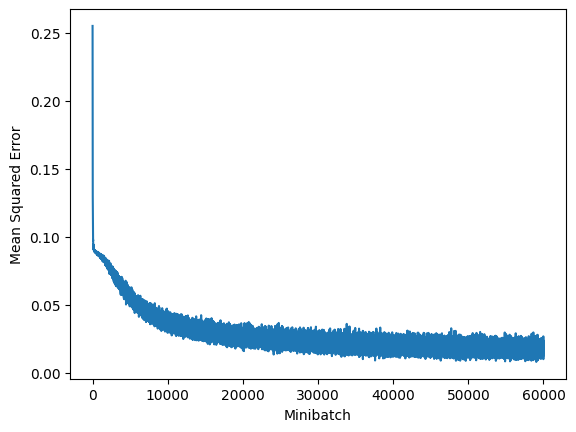

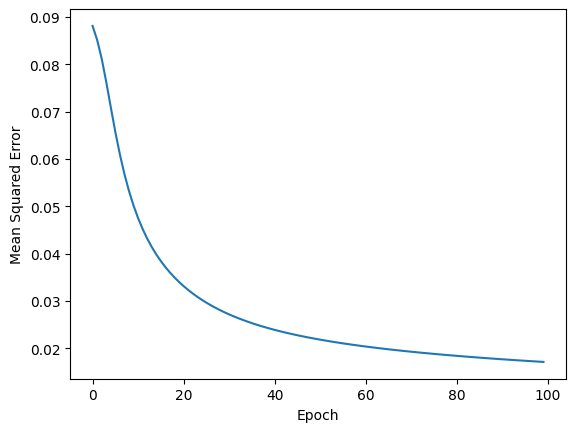

In [ ]:
plt.plot(range(len(minibatch_cost)), minibatch_cost)
plt.ylabel('Mean Squared Error')
plt.xlabel('Minibatch')
plt.show()

plt.plot(range(len(epoch_cost)), epoch_cost)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.show()

In [ ]:
def compute_accuracy(net, data_loader):
    correct_pred, num_examples = 0, 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)
            a1, a2 = net.forward(features)
            predicted_labels = torch.argmax(a2, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
        return correct_pred.float()/num_examples * 100

print('Training Accuracy: %.2f' % compute_accuracy(model, train_loader))
print('Test Accuracy: %.2f' % compute_accuracy(model, test_loader))

Training Accuracy: 90.78
Test Accuracy: 91.33


# MLP com função custo diferente - Cross Entropy

In [ ]:
import time
import numpy as np
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch

In [ ]:
RANDOM_SEED = 1
BATCH_SIZE = 100
NUM_EPOCHS = 100
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##########################
### MNIST DATASET
##########################

# Note transforms.ToTensor() scales input images
# to 0-1 range
train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms.ToTensor())


train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Checking the dataset
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([100, 1, 28, 28])
Image label dimensions: torch.Size([100])


In [ ]:
class MLP(torch.nn.Module):

    def __init__(self, num_features, num_hidden, num_classes):
        super().__init__()

        self.num_classes = num_classes

        ### 1st hidden layer
        self.linear_1 = torch.nn.Linear(num_features, num_hidden)
        self.linear_1.weight.detach().normal_(0.0, 0.1)
        self.linear_1.bias.detach().zero_()

        ### Output layer
        self.linear_out = torch.nn.Linear(num_hidden, num_classes)
        self.linear_out.weight.detach().normal_(0.0, 0.1)
        self.linear_out.bias.detach().zero_()

    def forward(self, x):
        out = self.linear_1(x)
        out = torch.sigmoid(out)
        logits = self.linear_out(out)
        #probas = torch.softmax(logits, dim=1)
        return logits#, probas


#################################
### Model Initialization
#################################

torch.manual_seed(RANDOM_SEED)
model = MLP(num_features=28*28,
            num_hidden=100,
            num_classes=10)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

#################################
### Training
#################################

def compute_loss(net, data_loader):
    curr_loss = 0.
    with torch.no_grad():
        for cnt, (features, targets) in enumerate(data_loader):
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)
            logits = net(features)
            loss = F.cross_entropy(logits, targets)
            curr_loss += loss
        return float(curr_loss)/cnt



start_time = time.time()
minibatch_cost = []
epoch_cost = []
for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):

        features = features.view(-1, 28*28).to(DEVICE)
        targets = targets.to(DEVICE)

        ### FORWARD AND BACK PROP
        logits = model(features)

        cost = F.cross_entropy(logits, targets)
        optimizer.zero_grad()

        cost.backward()

        ### UPDATE MODEL PARAMETERS
        optimizer.step()

        ### LOGGING
        minibatch_cost.append(cost.item())
        if not batch_idx % 50:
            print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f'
                   %(epoch+1, NUM_EPOCHS, batch_idx,
                     len(train_loader), cost.item()))

    cost = compute_loss(model, train_loader)
    epoch_cost.append(cost)
    print('Epoch: %03d/%03d Train Cost: %.4f' % (
            epoch+1, NUM_EPOCHS, cost))
    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/100 | Batch 000/600 | Cost: 2.5604
Epoch: 001/100 | Batch 050/600 | Cost: 1.8231
Epoch: 001/100 | Batch 100/600 | Cost: 1.4972
Epoch: 001/100 | Batch 150/600 | Cost: 1.1972
Epoch: 001/100 | Batch 200/600 | Cost: 0.8770
Epoch: 001/100 | Batch 250/600 | Cost: 0.8388
Epoch: 001/100 | Batch 300/600 | Cost: 0.7779
Epoch: 001/100 | Batch 350/600 | Cost: 0.7459
Epoch: 001/100 | Batch 400/600 | Cost: 0.6769
Epoch: 001/100 | Batch 450/600 | Cost: 0.5171
Epoch: 001/100 | Batch 500/600 | Cost: 0.5568
Epoch: 001/100 | Batch 550/600 | Cost: 0.5620
Epoch: 001/100 Train Cost: 0.4960
Time elapsed: 0.26 min
Epoch: 002/100 | Batch 000/600 | Cost: 0.4814
Epoch: 002/100 | Batch 050/600 | Cost: 0.4956
Epoch: 002/100 | Batch 100/600 | Cost: 0.3412
Epoch: 002/100 | Batch 150/600 | Cost: 0.3469
Epoch: 002/100 | Batch 200/600 | Cost: 0.4675
Epoch: 002/100 | Batch 250/600 | Cost: 0.3761
Epoch: 002/100 | Batch 300/600 | Cost: 0.4029
Epoch: 002/100 | Batch 350/600 | Cost: 0.4599
Epoch: 002/100 | Batch 

### **Classe `MLP` - Definição do Modelo**

```python
class MLP(torch.nn.Module):
```

Aqui, estamos definindo uma classe chamada **MLP** (Perceptron Multicamadas), que herda de **`torch.nn.Module`**. Isso permite que a classe se beneficie de todas as funcionalidades que a PyTorch oferece para modelos de redes neurais (como o gerenciamento de parâmetros e o cálculo automático de gradientes).

---

#### **Método `__init__` - Inicialização do Modelo**

```python
def __init__(self, num_features, num_hidden, num_classes):
    super().__init__()
    self.num_classes = num_classes
```

- **`__init__`**: Este é o inicializador do modelo, que define a arquitetura da rede.
- **`super().__init__()`**: Chama o inicializador da classe pai (**`torch.nn.Module`**), garantindo que a funcionalidade padrão do PyTorch seja inicializada corretamente.
- **`self.num_classes = num_classes`**: Armazena o número de classes de saída (no caso, 10 para os 10 dígitos de 0 a 9 do MNIST).

---

#### **Primeira Camada Oculta**

```python
self.linear_1 = torch.nn.Linear(num_features, num_hidden)
self.linear_1.weight.detach().normal_(0.0, 0.1)
self.linear_1.bias.detach().zero_()
```

- **`self.linear_1 = torch.nn.Linear(num_features, num_hidden)`**: Define a primeira camada oculta da rede. Esta camada tem `num_features` entradas e `num_hidden` neurônios. No caso do MNIST, `num_features` será 28x28 (784) porque cada imagem tem 28x28 pixels, e `num_hidden` é o número de neurônios na camada oculta (100 no exemplo).
- **`self.linear_1.weight.detach().normal_(0.0, 0.1)`**: Inicializa os pesos da camada com uma distribuição normal com média 0 e desvio padrão 0.1. **`detach()`** é usado para garantir que os pesos não serão afetados por operações que não fazem parte do gráfico de autograd.
- **`self.linear_1.bias.detach().zero_()`**: Inicializa o viés (bias) da camada com 0.

---

#### **Camada de Saída**

```python
self.linear_out = torch.nn.Linear(num_hidden, num_classes)
self.linear_out.weight.detach().normal_(0.0, 0.1)
self.linear_out.bias.detach().zero_()
```

- **`self.linear_out = torch.nn.Linear(num_hidden, num_classes)`**: Define a camada de saída, que conecta os `num_hidden` neurônios da camada oculta aos `num_classes` neurônios de saída. Para o MNIST, `num_classes` é 10, representando os 10 dígitos possíveis.
- **`self.linear_out.weight.detach().normal_(0.0, 0.1)`**: Inicializa os pesos da camada de saída com uma distribuição normal com média 0 e desvio padrão 0.1.
- **`self.linear_out.bias.detach().zero_()`**: Inicializa o viés da camada de saída com 0.

---

#### **Método `forward` - Propagação para Frente (Forward Pass)**

```python
def forward(self, x):
    out = self.linear_1(x)
    out = torch.sigmoid(out)
    logits = self.linear_out(out)
    return logits
```

- **`forward(self, x)`**: Define como a entrada `x` (um lote de imagens) passa pelas camadas da rede durante a propagação para frente.
- **`out = self.linear_1(x)`**: A entrada `x` é passada pela primeira camada oculta (`linear_1`).
- **`out = torch.sigmoid(out)`**: Aplica a função de ativação **sigmóide** à saída da camada oculta. A função sigmóide mapeia os valores para um intervalo entre 0 e 1.
- **`logits = self.linear_out(out)`**: A saída da camada oculta é passada pela camada de saída (`linear_out`).
- **`return logits`**: Retorna os logits (valores antes de aplicar a função de ativação na camada de saída, ou seja, os valores brutos).

> **Nota**: A função `torch.softmax()` foi comentada. Se fosse usada, ela normalizaria os logits para probabilidades, o que é útil para problemas de classificação multi-classe, mas neste caso o **`cross_entropy`** cuida da normalização internamente.

---

### **Inicialização do Modelo e do Otimizador**

```python
torch.manual_seed(RANDOM_SEED)
model = MLP(num_features=28*28, num_hidden=100, num_classes=10)
model = model.to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
```

- **`torch.manual_seed(RANDOM_SEED)`**: Configura uma semente aleatória para garantir que os resultados sejam reproduzíveis.
- **`model = MLP(num_features=28*28, num_hidden=100, num_classes=10)`**: Cria uma instância do modelo **MLP** com 784 entradas (28x28 pixels), 100 neurônios na camada oculta e 10 classes de saída (para MNIST).
- **`model = model.to(DEVICE)`**: Move o modelo para o dispositivo correto (GPU ou CPU).
- **`optimizer = torch.optim.SGD(model.parameters(), lr=0.1)`**: Define o otimizador **Stochastic Gradient Descent (SGD)** com uma taxa de aprendizado (`lr`) de 0.1. Ele irá otimizar os parâmetros do modelo (pesos e vieses).

---

### **Função de Cálculo da Perda (`compute_loss`)**

```python
def compute_loss(net, data_loader):
    curr_loss = 0.
    with torch.no_grad():
        for cnt, (features, targets) in enumerate(data_loader):
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)
            logits = net(features)
            loss = F.cross_entropy(logits, targets)
            curr_loss += loss
        return float(curr_loss)/cnt
```

- **`torch.no_grad()`**: Desativa o cálculo de gradientes, o que economiza memória e tempo de computação durante a avaliação do modelo.
- **`for cnt, (features, targets) in enumerate(data_loader)`**: Itera sobre o conjunto de dados fornecido pelo `data_loader`. **`features`** são as imagens e **`targets`** são os rótulos (dígitos reais).
- **`features.view(-1, 28*28).to(DEVICE)`**: Achata as imagens 28x28 para vetores de 784 dimensões e move os dados para o dispositivo correto.
- **`logits = net(features)`**: Passa as imagens através do modelo (computando os logits).
- **`loss = F.cross_entropy(logits, targets)`**: Calcula a perda de **entropia cruzada** entre os logits e os rótulos reais. Essa função de perda é usada para problemas de classificação multi-classe.
- **`curr_loss += loss`**: Acumula a perda para o cálculo final.
- **`return float(curr_loss)/cnt`**: Retorna a perda média por lote.

---

### **Loop de Treinamento**

```python
start_time = time.time()
minibatch_cost = []
epoch_cost = []
for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
```

- **`model.train()`**: Coloca o modelo no modo de treinamento, ativando comportamentos como dropout (se houvesse) e cálculo de gradientes.
- **`for batch_idx, (features, targets) in enumerate(train_loader)`**: Itera sobre o conjunto de dados em mini-lotes.

#### **Propagação para Frente e Retropropagação**

```python
logits = model(features)
cost = F.cross_entropy(logits, targets)
optimizer.zero_grad()
cost.backward()
optimizer.step()
```

- **`logits = model(features)`**: Passa os dados de entrada (`features`) pela rede para obter os logits.
- **`cost = F.cross_entropy(logits, targets)`**: Calcula a perda (erro) entre os logits e os rótulos reais (`targets`).
- **`optimizer.zero_grad()`**: Zera os gradientes acumulados de uma iteração anterior.
- **`cost.backward()`**: Calcula os gradientes com base na perda.
- **`optimizer.step()`**: Atualiza os parâmetros do modelo (pesos e vieses) com base nos gradientes calculados.

#### **Logging**

```python
minibatch_cost.append(cost.item())
if not batch_idx % 50:
    print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f'
           %(epoch+1, NUM_EPOCHS, batch_idx,
             len(train_loader), cost.item()))
```

- **`minibatch_cost.append(cost.item())`**: Armazena o custo de cada mini-batch para posterior visualização.
- **`if not batch_idx % 50:`**: A cada 50 mini-batches, exibe o progresso do treinamento (número da época, número do mini-batch e o custo).

---

### **Finalização do Treinamento**

```python
cost = compute_loss(model, train_loader)
epoch_cost.append(cost)
print('Epoch: %03d/%03d Train Cost: %.4f' % (epoch+1, NUM_EPOCHS, cost))
print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
```

- **`cost = compute_loss(model, train_loader)`**: Calcula a perda média para a época inteira.
- **`epoch_cost.append(cost)`**: Armazena o custo médio por época.
- **`print('Epoch: %03d/%03d Train Cost: %.4f' % (epoch+1, NUM_EPOCHS, cost))`**: Exibe o custo médio da época.
- **`print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))`**: Exibe o tempo total gasto no treinamento até aquele ponto.



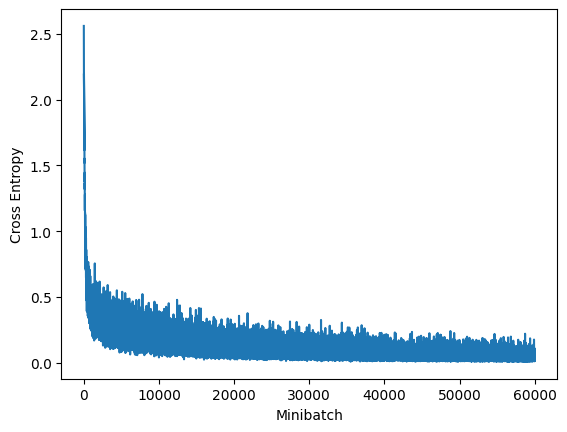

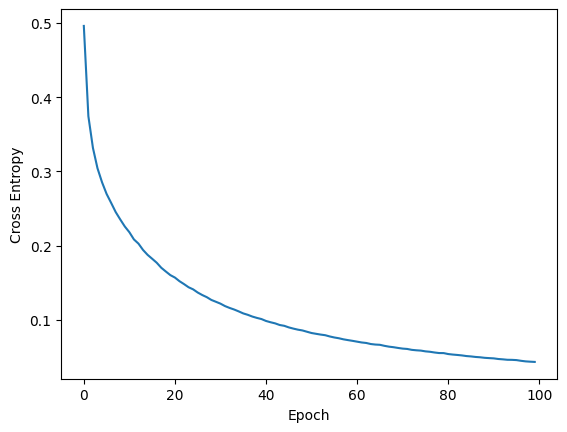

In [ ]:
plt.plot(range(len(minibatch_cost)), minibatch_cost)
plt.ylabel('Cross Entropy')
plt.xlabel('Minibatch')
plt.show()

plt.plot(range(len(epoch_cost)), epoch_cost)
plt.ylabel('Cross Entropy')
plt.xlabel('Epoch')
plt.show()

In [ ]:
def compute_accuracy(net, data_loader):
    correct_pred, num_examples = 0, 0
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)
            logits = net.forward(features)
            predicted_labels = torch.argmax(logits, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
        return correct_pred.float()/num_examples * 100

print('Training Accuracy: %.2f' % compute_accuracy(model, train_loader))
print('Test Accuracy: %.2f' % compute_accuracy(model, test_loader))

Training Accuracy: 98.99
Test Accuracy: 97.68


# Usando torch Sequential

In [ ]:
SETTINGS = {'random seed': 1,
'num class labels': 10,
'learning rate': 0.001,
'batch size': 128,
'input size': 784,
'hidden layer size': 100,
'num epochs': 10,
'cuda device': 0,
'num workers': 0,
'validation fraction': 0.1}

In [ ]:
class MLP(torch.nn.Module):

    def __init__(self, num_features, num_hidden, num_classes):
        super().__init__()

        self.num_classes = num_classes

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(num_features, num_hidden),  # Hidden Layer
            torch.nn.Sigmoid(),
            torch.nn.Linear(num_hidden, num_classes)  # Output layer
        )

    def forward(self, x):
        return self.classifier(x)


model = MLP(num_features=SETTINGS['input size'],
            num_hidden=SETTINGS['hidden layer size'],
            num_classes=SETTINGS['num class labels'])
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=SETTINGS['learning rate'])


start_time = time.time()
minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []
for epoch in range(SETTINGS['num epochs']):

    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):

        features = features.to(device)
        targets = targets.to(device)

        # ## FORWARD AND BACK PROP
        logits = model(features)
        loss = torch.nn.functional.cross_entropy(logits, targets)
        optimizer.zero_grad()

        loss.backward()

        # ## UPDATE MODEL PARAMETERS
        optimizer.step()

        # ## LOGGING
        minibatch_loss_list.append(loss.item())
        if not batch_idx % 50:
            print(f'Epoch: {epoch+1:03d}/{SETTINGS["num epochs"]:03d} '
                  f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                  f'| Loss: {loss:.4f}')

    model.eval()
    with torch.no_grad():  # save memory during inference
        train_acc = compute_accuracy(model, train_loader, device=device)
        valid_acc = compute_accuracy(model, valid_loader, device=device)
        print(f'Epoch: {epoch+1:03d}/{SETTINGS["num epochs"]:03d} '
              f'| Train: {train_acc :.2f}% '
              f'| Validation: {valid_acc :.2f}%')
        train_acc_list.append(train_acc.item())
        valid_acc_list.append(valid_acc.item())

    elapsed = (time.time() - start_time)/60
    print(f'Time elapsed: {elapsed:.2f} min')

elapsed = (time.time() - start_time)/60
print(f'Total Training Time: {elapsed:.2f} min')

test_acc = compute_accuracy(model, test_loader, device=device)
print(f'Test accuracy {test_acc :.2f}%')


Vamos dividir e explicar o código em detalhes, além de sugerir possíveis melhorias.

---

### **Classe MLP: Definição do Modelo**

```python
class MLP(torch.nn.Module):
    def __init__(self, num_features, num_hidden, num_classes):
        super().__init__()

        self.num_classes = num_classes

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(num_features, num_hidden),  # Hidden Layer
            torch.nn.Sigmoid(),
            torch.nn.Linear(num_hidden, num_classes)  # Output layer
        )
```

1. **Classe `MLP`**: O modelo é uma rede neural de Perceptron Multicamadas (MLP). Ele herda de **`torch.nn.Module`**, que é a classe base para a maioria dos modelos em PyTorch.
   
2. **Método `__init__`**:
   - **`num_features`**: Número de entradas (features) da rede (por exemplo, o número de pixels em uma imagem do MNIST).
   - **`num_hidden`**: Número de neurônios na camada oculta da rede.
   - **`num_classes`**: Número de classes de saída (para MNIST, seriam 10, uma para cada dígito).

3. **`self.classifier`**: Aqui está definida a arquitetura da rede utilizando **`torch.nn.Sequential`**, que agrupa camadas de forma sequencial.
   - **`torch.nn.Flatten()`**: Achata a entrada (por exemplo, uma imagem 2D de 28x28 pixels) em um vetor unidimensional de tamanho `28*28 = 784`.
   - **`torch.nn.Linear(num_features, num_hidden)`**: Camada totalmente conectada (densa) que recebe `num_features` entradas e gera `num_hidden` saídas.
   - **`torch.nn.Sigmoid()`**: Função de ativação sigmoide que introduz não-linearidade, mapeando a saída da camada oculta para o intervalo [0, 1].
   - **`torch.nn.Linear(num_hidden, num_classes)`**: Camada de saída, com `num_hidden` entradas e `num_classes` saídas (gerando os logits para cada classe).

---

### **Método `forward`: Propagação para Frente**

```python
def forward(self, x):
    return self.classifier(x)
```

- **`forward(self, x)`**: Método de propagação para frente (forward pass). Ele simplesmente passa os dados de entrada `x` pela rede definida em `self.classifier`, que contém todas as camadas da rede.

---

### **Instanciação e Configuração do Modelo e Otimizador**

```python
model = MLP(num_features=SETTINGS['input size'],
            num_hidden=SETTINGS['hidden layer size'],
            num_classes=SETTINGS['num class labels'])
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=SETTINGS['learning rate'])
```

1. **Instanciação do Modelo**:
   - **`SETTINGS['input size']`**, **`SETTINGS['hidden layer size']`**, **`SETTINGS['num class labels']`**: Esses parâmetros vêm de um dicionário **`SETTINGS`**, que define as configurações da rede. Eles são passados para a classe `MLP` ao criar o modelo.
   - **`model.to(device)`**: Move o modelo para o dispositivo correto, seja **CPU** ou **GPU** (dependendo do que está disponível).

2. **Definição do Otimizador**:
   - **`torch.optim.Adam(model.parameters(), lr=SETTINGS['learning rate'])`**: Cria o otimizador **Adam** para otimizar os parâmetros do modelo (pesos e vieses). A taxa de aprendizado (**learning rate**) é definida em **`SETTINGS['learning rate']`**.

---

### **Treinamento do Modelo**

#### **Loop de Treinamento**

```python
start_time = time.time()
minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []
for epoch in range(SETTINGS['num epochs']):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):

        features = features.to(device)
        targets = targets.to(device)

        # ## FORWARD AND BACK PROP
        logits = model(features)
        loss = torch.nn.functional.cross_entropy(logits, targets)
        optimizer.zero_grad()

        loss.backward()

        # ## UPDATE MODEL PARAMETERS
        optimizer.step()

        # ## LOGGING
        minibatch_loss_list.append(loss.item())
        if not batch_idx % 50:
            print(f'Epoch: {epoch+1:03d}/{SETTINGS["num epochs"]:03d} '
                  f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                  f'| Loss: {loss:.4f}')
```

1. **`start_time = time.time()`**: Marca o tempo de início do treinamento para cálculo do tempo total de execução.
   
2. **`minibatch_loss_list`, `train_acc_list`, `valid_acc_list`**: Listas para armazenar as perdas e as acurácias do treinamento e validação por época.

3. **`for epoch in range(SETTINGS['num epochs'])`**: O loop de treinamento vai iterar por várias épocas, dependendo de **`SETTINGS['num epochs']`**.

4. **`model.train()`**: Coloca o modelo em modo de treinamento, o que permite que operações como dropout (se fossem usadas) ocorram.

5. **`for batch_idx, (features, targets) in enumerate(train_loader)`**: O loop itera sobre o **`train_loader`**, que é o carregador de dados para os dados de treinamento. **`features`** são as entradas (imagens) e **`targets`** são os rótulos (as classes para cada imagem).

6. **`features = features.to(device)`** e **`targets = targets.to(device)`**: Move as entradas e os rótulos para o dispositivo correto (GPU ou CPU).

7. **`logits = model(features)`**: Faz a propagação para frente no modelo para obter os logits (valores antes da função de ativação softmax).

8. **`loss = torch.nn.functional.cross_entropy(logits, targets)`**: Calcula a perda de **entropia cruzada**, que é adequada para problemas de classificação multi-classe.

9. **`optimizer.zero_grad()`**: Zera os gradientes acumulados dos parâmetros do modelo (necessário antes de calcular novos gradientes).

10. **`loss.backward()`**: Calcula os gradientes da perda em relação aos parâmetros do modelo.

11. **`optimizer.step()`**: Atualiza os parâmetros do modelo usando os gradientes calculados.

12. **`minibatch_loss_list.append(loss.item())`**: Armazena a perda do mini-lote atual.

13. **`if not batch_idx % 50:`**: A cada 50 mini-batches, exibe o progresso do treinamento, incluindo a época, o número do mini-batch e a perda.

---

#### **Avaliação do Modelo Após Cada Época**

```python
model.eval()
with torch.no_grad():  # save memory during inference
    train_acc = compute_accuracy(model, train_loader, device=device)
    valid_acc = compute_accuracy(model, valid_loader, device=device)
    print(f'Epoch: {epoch+1:03d}/{SETTINGS["num epochs"]:03d} '
          f'| Train: {train_acc :.2f}% '
          f'| Validation: {valid_acc :.2f}%')
    train_acc_list.append(train_acc.item())
    valid_acc_list.append(valid_acc.item())
```

1. **`model.eval()`**: Coloca o modelo em modo de avaliação, desativando comportamentos como dropout (se fossem usados).

2. **`with torch.no_grad()`**: Desativa o cálculo de gradientes durante a avaliação, economizando memória e tempo de computação.

3. **`train_acc = compute_accuracy(model, train_loader, device=device)`** e **`valid_acc = compute_accuracy(model, valid_loader, device=device)`**: Calcula as acurácias de treinamento e validação usando a função **`compute_accuracy`** (que não está fornecida, mas presumivelmente calcula a porcentagem de classificações corretas).

4. **`train_acc_list.append(train_acc.item())`** e **`valid_acc_list.append(valid_acc.item())`**: Armazena as acurácias de treinamento e validação.

5. **Exibição das Acurácias**: Imprime as acurácias de treinamento e validação para a época atual.

---

#### **Cálculo do Tempo Decorrido e Finalização do Treinamento**

```python
elapsed = (time.time() - start_time)/60
print(f'Time elapsed: {elapsed:.2f} min')

elapsed = (time.time() - start_time)/60
print(f'Total Training Time: {elapsed:.2f} min')

test_acc = compute_accuracy(model, test_loader, device=device)
print(f'Test accuracy {test_acc :.2f}%')
```

1. **Cálculo e exibição do tempo decorrido**: O tempo total de treinamento é calculado e exibido em minutos após cada época.

2. **Avaliação no Teste**: Após o treinamento, a acurácia final no conjunto de teste é calculada e exibida.



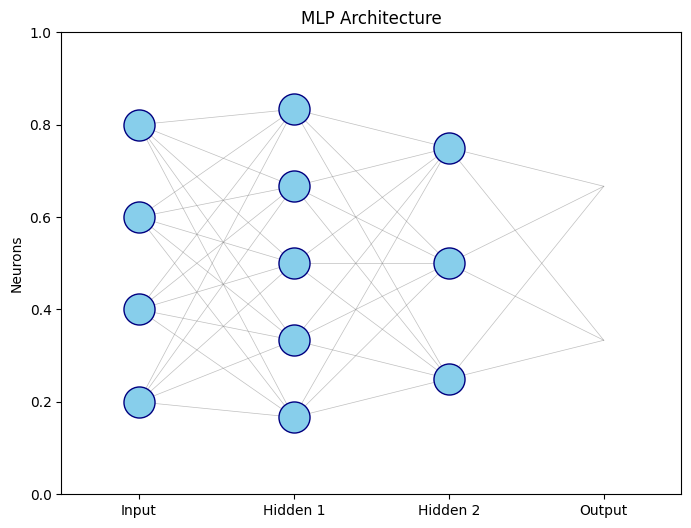

In [ ]:
import matplotlib.pyplot as plt

def plot_mlp(layer_sizes):
    plt.figure(figsize=(8, 6))
    layers = len(layer_sizes)

    # Desenha os nós e conexões
    for i, (n_neurons, next_neurons) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        # Posições dos nós na camada atual e próxima
        x_current = [i + 0.5] * n_neurons
        y_current = [k / (n_neurons + 1) for k in range(1, n_neurons + 1)]

        x_next = [i + 1.5] * next_neurons
        y_next = [k / (next_neurons + 1) for k in range(1, next_neurons + 1)]

        # Conexões entre camadas
        for yc in y_current:
            for yn in y_next:
                plt.plot([i + 0.5, i + 1.5], [yc, yn], 'gray', lw=0.5, alpha=0.5)

        # Nós da camada atual
        plt.scatter(x_current, y_current, s=500, c='skyblue', edgecolors='navy', zorder=2)

    # Configurações do gráfico
    plt.xticks([0.5 + i for i in range(layers)], ['Input', 'Hidden 1', 'Hidden 2', 'Output'][:layers])
    plt.xlim(0, layers)
    plt.ylim(0, 1)
    plt.ylabel("Neurons")
    plt.title("MLP Architecture")
    plt.grid(False)
    plt.show()

# Exemplo: 4 (entrada) → 5 (oculta 1) → 3 (oculta 2) → 2 (saída)
plot_mlp([4, 5, 3, 2])